## Neural Networks

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
EEA = pd.read_csv('reduced_EEA_2023.csv')

In [3]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,1175.0,129.0,petrol,999.0,70.0
1,1122.0,117.0,petrol,999.0,59.0
2,1588.0,126.0,diesel,1968.0,110.0
3,1516.0,124.0,diesel,1968.0,110.0
4,1349.0,126.0,petrol,1498.0,110.0


### Categorical into dummies

In [4]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [5]:
EEA = EEA.astype(int)

In [6]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


### Model 4 - Neural Networks

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [17]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1. Define features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# 2. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the neural network model

dl_model = Sequential()
# Input layer
dl_model.add(Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

# Hidden layers
dl_model.add(Dense(128, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(64, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32, activation='relu'))
dl_model.add(BatchNormalization())
dl_model.add(Dropout(0.2))

dl_model.add(Dense(16, activation='relu'))
dl_model.add(Dropout(0.1))

# Output layer
dl_model.add(Dense(1, activation='linear'))  # Linear for regression

# 5. Compile the model
dl_model.compile(optimizer=Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='mse', metrics=['mae'])

# Display model architecture
print("Model Architecture:")
dl_model.summary()

# 5. Setup callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.8,
    patience=15,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# 6. Train the model
history = dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# 7. Make predictions
y_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# 8. Calculate evaluation metrics (same as your RF model)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

# Print Evaluation Metrics (same format as your RF model)
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.3f}")


/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 27525.8906 - mae: 160.1271 - val_loss: 5769.7417 - val_mae: 61.6864 - learning_rate: 5.0000e-04
Epoch 2/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5077.2666 - mae: 58.2412 - val_loss: 698.6985 - val_mae: 17.3877 - learning_rate: 5.0000e-04
Epoch 3/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1945.8698 - mae: 33.9263 - val_loss: 501.3774 - val_mae: 14.8370 - learning_rate: 5.0000e-04
Epoch 4/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1799.7286 - mae: 32.5304 - val_loss: 460.6341 - val_mae: 14.1220 - learning_rate: 5.0000e-04
Epoch 5/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1642.5840 - mae: 30.8943 - val_loss: 479.7575 - val_mae: 13.8713 - learning_rate: 5.0000e-04
Epoch 6/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1540.9990 - mae: 29.9320 - val_loss: 432.1139 - val_mae: 13.8163 - learning_rate: 5.0000e-04
Epoch 7/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1452.2753 - 

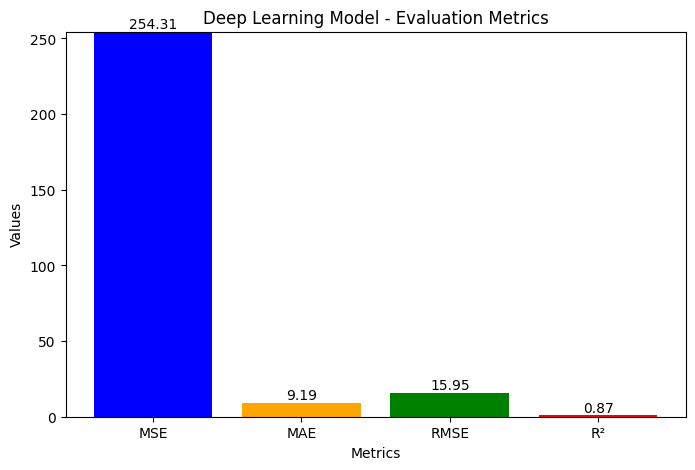

In [18]:
# 9. Visualize the metrics (same style as your RF model)
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
values = [mse, mae, rmse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'red'])
plt.title('Deep Learning Model - Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Adjust the y-axis for better readability (e.g., for R²)
plt.ylim([0, max(values) + 0.1])

# Display the value labels above the bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom')

# Show plot
plt.show()

Train MSE: 236.84
Test MSE: 254.31
Train MAE: 9.09
Test MAE: 9.19
Train RMSE: 15.39
Test RMSE: 15.95
Train R² Score: 0.881
Test R² Score: 0.871


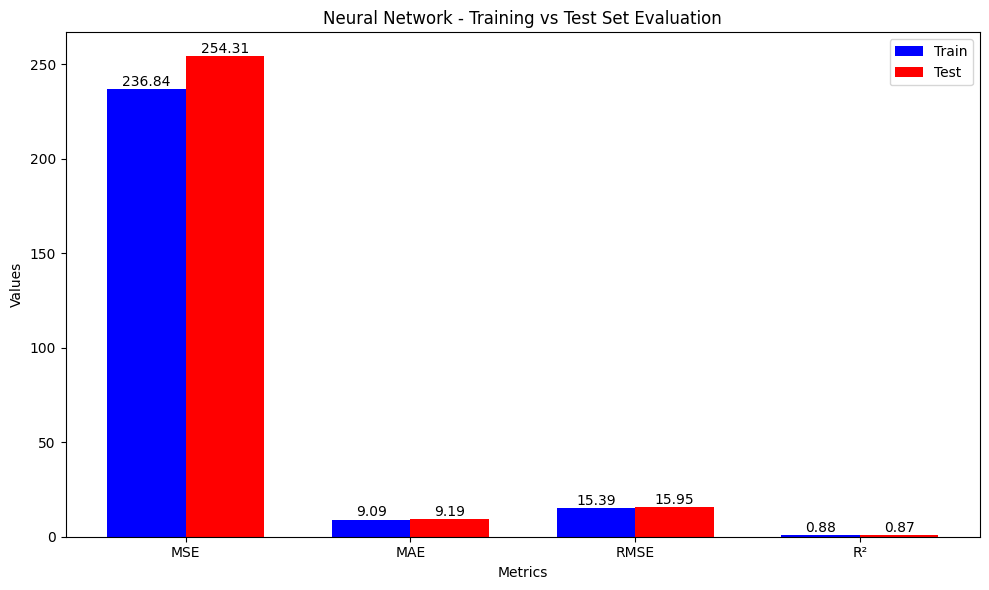

In [24]:

# 1. Predictions for Training and Test Set
y_train_pred = dl_model.predict(X_train_scaled, verbose=0).flatten()
y_test_pred = dl_model.predict(X_test_scaled, verbose=0).flatten()

# 2. Calculate MSE, MAE, RMSE, and R² for Training and Test Set
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 3. Print Evaluation Metrics
print(f"Train MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Train R² Score: {train_r2:.3f}")
print(f"Test R² Score: {test_r2:.3f}")

# 4. Create a graph to compare metrics for Training vs Test set
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
train_values = [train_mse, train_mae, train_rmse, train_r2]
test_values = [test_mse, test_mae, test_rmse, test_r2]

# Create the bar chart
bar_width = 0.35
index = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.bar(index, train_values, bar_width, label='Train', color='blue')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='red')

# Add labels and title
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Neural Network - Training vs Test Set Evaluation')
plt.xticks(index + bar_width / 2, metrics)
plt.legend()

# Display the values on top of the bars
for i, value in enumerate(train_values):
    plt.text(i, value + 0.05, f"{value:.2f}", ha='center', va='bottom')
for i, value in enumerate(test_values):
    plt.text(i + bar_width, value + 0.05, f"{value:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()



We don't see much difference between training & validation results for MSE, MAE, and RMSE, indicating the model generalizes well, while the R² score of 0.87 shows it explains 87% of the variance in the training set.

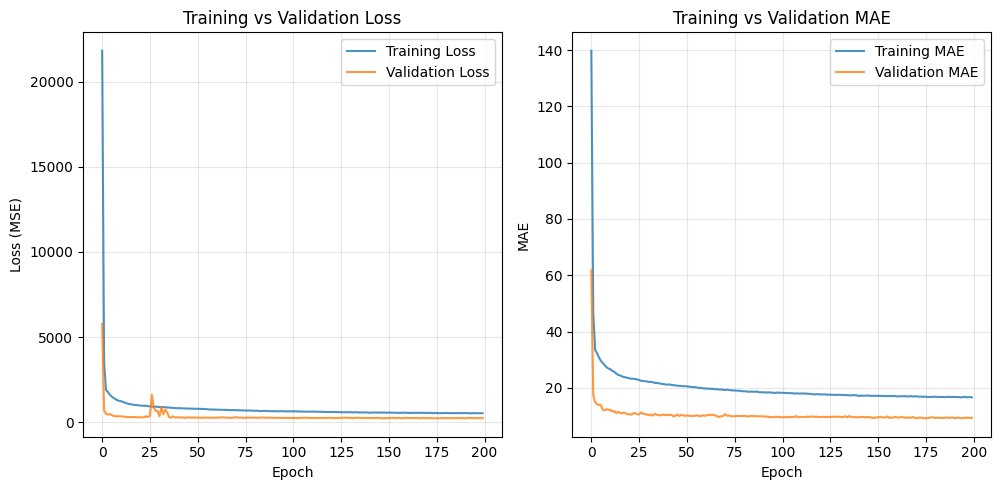

In [ ]:

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss', alpha=0.8)
plt.plot(history.history['val_loss'], label='Validation Loss', alpha=0.8)
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE', alpha=0.8)
plt.plot(history.history['val_mae'], label='Validation MAE', alpha=0.8)
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning rate schedule
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Calculating feature importance (this may take a moment)...
Feature Importance Rankings:
Mass_in_Running_Order(kg): 1.3385
Engine_Capacity(cm3): 0.7175
Fuel_Type_petrol: 0.2520
Engine_Power(kW): 0.1970


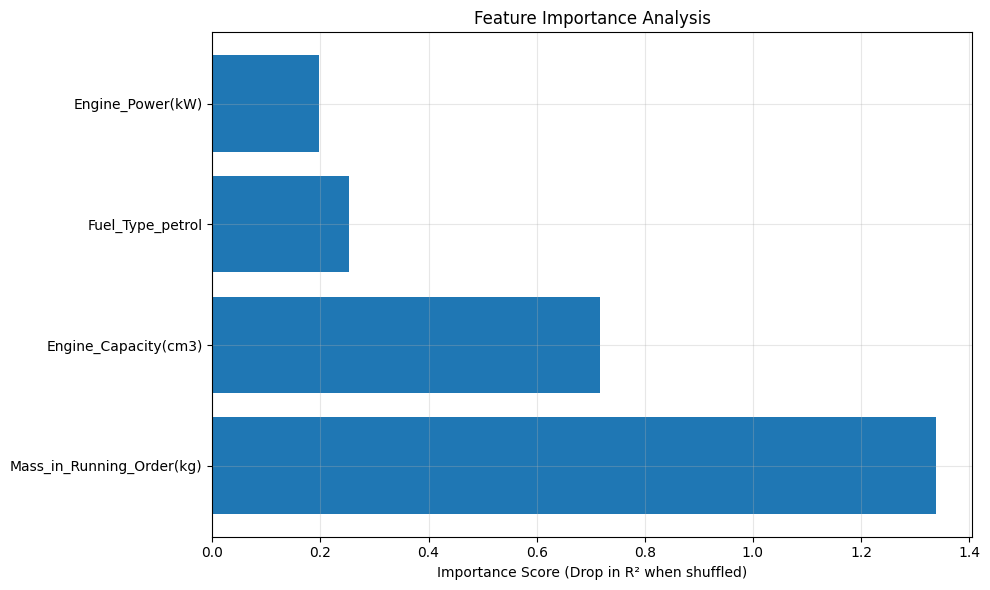

In [27]:
# Feature Importance Analysis

# Simple feature importance using permutation
feature_names = X.columns.tolist()
baseline_score = r2_score(y_test, y_pred)
feature_importance = []

print("Calculating feature importance (this may take a moment)...")
for i, feature in enumerate(feature_names):
    # Create a copy and shuffle one feature
    X_test_permuted = X_test_scaled.copy()
    np.random.shuffle(X_test_permuted[:, i])
    
    # Get predictions with shuffled feature
    y_pred_permuted = dl_model.predict(X_test_permuted, verbose=0).flatten()
    permuted_score = r2_score(y_test, y_pred_permuted)
    
    # Importance = drop in performance
    importance = baseline_score - permuted_score
    feature_importance.append(importance)

# Create feature importance dataframe
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
for idx, row in feature_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_df)), feature_df['Importance'])
plt.yticks(range(len(feature_df)), feature_df['Feature'])
plt.xlabel('Importance Score (Drop in R² when shuffled)')
plt.title('Feature Importance Analysis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()